# Successive Variational Mode Decomposition (SVMD)

This notebook introduces **Successive Variational Mode Decomposition (SVMD)** and demonstrates it with PySDKit.

## Motivation

Classical **VMD** extracts `K` compact-spectrum modes **concurrently**.  That is powerful, but:

- `K` must be known (or guessed) in advance;
- over-/under-segmentation causes mode mixing or duplicated bands;
- the joint ADMM problem grows with `K`.

**SVMD** keeps the variational idea of VMD (each mode is a narrowband signal around a center frequency), but extracts modes **one by one** and stops automatically.  No preset `K` is required.

**Reference**

> M. Nazari, S. M. Sakhaei.  
> *Successive Variational Mode Decomposition.*  
> Signal Processing, 174:107610, 2020.  
> https://doi.org/10.1016/j.sigpro.2020.107610


## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "examples":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path and (ROOT / "pysdkit").exists():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SVMD, VMD, svmd

print(SVMD())

Successive Variational Mode Decomposition (SVMD)


## 2. Core idea (from the paper)

VMD models each mode $u_k$ as an AM–FM signal whose spectrum is concentrated around a center frequency $\omega_k$.  The joint problem is

$$
\min_{\{u_k\},\{\omega_k\}}
\sum_{k=1}^{K}
\left\|
\partial_t
\Big[
\big(\delta(t)+\tfrac{j}{\pi t}\big)*u_k(t)
\Big]
e^{-j\omega_k t}
\right\|_2^2
\quad\text{s.t.}\quad
\sum_{k=1}^{K} u_k = f.
$$

SVMD instead looks for **one new mode** $u_L$ at a time.  Besides compactness of $u_L$, it adds two extra goals:

1. **little overlap with already extracted modes** $\{u_i\}_{i<L}$;
2. **little overlap with the residual** $f - u_L - \sum_{i<L} u_i$.

In the Fourier domain this yields an ADMM update of the form

$$
\hat u_L^{n+1}(\omega)
=
\frac{
\hat f(\omega)
+ \alpha^2(\omega-\omega_L)^4\,\hat u_L^{n}(\omega)
+ \hat\lambda^{n}/2
}{
1 + \alpha^2(\omega-\omega_L)^4\big(1+2\alpha(\omega-\omega_L)^2\big)
+ \sum_{i<L}\hat h_i(\omega)
},
$$

where the filters $\hat h_i$ suppress previously found bands, and $\alpha$ is gradually increased from a small value up to `max_alpha` so that each mode becomes spectrally pure.

The center frequency is the power-weighted mean on the positive spectrum:

$$
\omega_L^{n+1}
=
\frac{
\int_{0}^{\infty}\omega\,|\hat u_L^{n+1}(\omega)|^2\,d\omega
}{
\int_{0}^{\infty}|\hat u_L^{n+1}(\omega)|^2\,d\omega
}.
$$

After a mode converges, SVMD decides whether to stop using one of four criteria (`stopc`):

| `stopc` | Criterion | Typical use |
|--------:|-----------|-------------|
| 1 | residual power ≈ estimated noise | EEG / noisy, compact spectra |
| 2 | relative reconstruction error | clean signals |
| 3 | Bayesian information criterion (BIC) | model-order selection |
| 4 | power of the last mode (default) | general purpose |


## 3. Synthetic example (three tones)

We build a clean mixture of 3 Hz, 25 Hz and 60 Hz — the same style of example used in the SVMD paper / MATLAB demo.


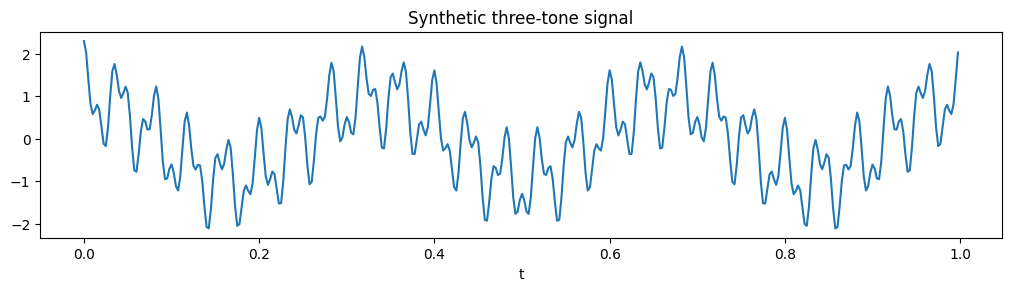

In [2]:
n = 400
t = np.linspace(0.0, 1.0, n, endpoint=False)
f1, f2, f3 = 3.0, 25.0, 60.0
signal = (
    np.cos(2 * np.pi * f1 * t)
    + 0.8 * np.cos(2 * np.pi * f2 * t)
    + 0.5 * np.cos(2 * np.pi * f3 * t)
)

fig, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
ax.plot(t, signal, color="C0")
ax.set_title("Synthetic three-tone signal")
ax.set_xlabel("t")
plt.show()

## 4. Run SVMD (`stopc=2` for exact reconstruction)

With a clean signal we use **stopc = 2**, which stops when the residual energy is small.  SVMD should recover **three** modes whose normalized center frequencies sit near $f/N$.


In [3]:
svmd_c = SVMD(max_alpha=5000, tau=0.0, tol=1e-6, stopc=2, max_iter=250)
modes, u_hat, omega = svmd_c.fit_transform(signal, return_all=True)

print("modes shape (L, N):", modes.shape)
print("center frequencies (normalized):", omega)
print("center frequencies (Hz, fs=N):   ", omega * n)

recon = modes.sum(axis=0)
rel_err = np.linalg.norm(recon - signal) / np.linalg.norm(signal)
print(f"reconstruction relative error: {rel_err:.3e}")

modes shape (L, N): (3, 400)
center frequencies (normalized): [0.0074987  0.06248649 0.15000172]
center frequencies (Hz, fs=N):    [ 2.99948129 24.99459558 60.00068893]
reconstruction relative error: 3.321e-02


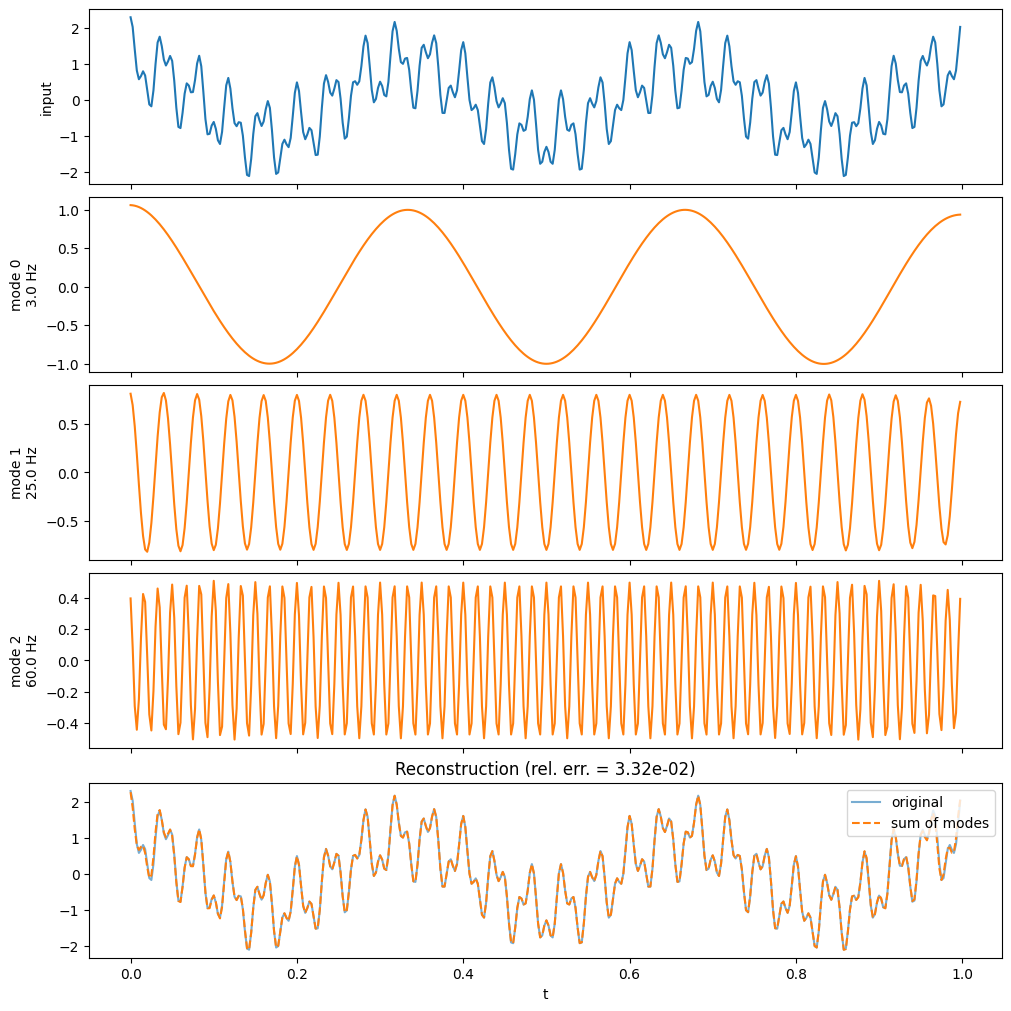

In [ ]:
L = modes.shape[0]
fig, axes = plt.subplots(
    L + 2, 1, figsize=(10, 2.0 * (L + 2)), sharex=True, constrained_layout=True
)

axes[0].plot(t, signal, color="C0")
axes[0].set_ylabel("input")

for k in range(L):
    axes[k + 1].plot(t, modes[k], color="C1")
    axes[k + 1].set_ylabel(f"mode {k}\n{omega[k]*n:.1f} Hz")

axes[-1].plot(t, signal, alpha=0.6, label="original")
axes[-1].plot(t, recon, "--", label="sum of modes")
axes[-1].legend(loc="upper right")
axes[-1].set_xlabel("t")
axes[-1].set_title(f"Reconstruction (rel. err. = {rel_err:.2e})")
plt.show()

## 5. Spectra of the extracted modes

Each mode should occupy a narrow band around its estimated $\omega_L$.


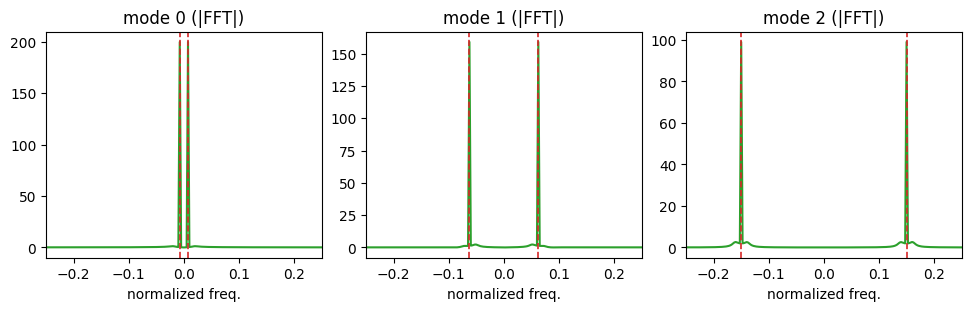

In [5]:
freqs = np.linspace(-0.5, 0.5, n, endpoint=False)

fig, axes = plt.subplots(1, L, figsize=(3.2 * L, 3.0), constrained_layout=True)
if L == 1:
    axes = [axes]
for k, ax in enumerate(axes):
    ax.plot(freqs, np.abs(u_hat[:, k]), color="C2")
    ax.axvline(omega[k], color="C3", ls="--", lw=1.2)
    ax.axvline(-omega[k], color="C3", ls="--", lw=1.2)
    ax.set_xlim(-0.25, 0.25)
    ax.set_title(f"mode {k} (|FFT|)")
    ax.set_xlabel("normalized freq.")
plt.show()

## 6. SVMD vs VMD

VMD needs `K` in advance.  With the correct `K=3` it should match SVMD; with a wrong `K` it degrades.  SVMD avoids that choice.


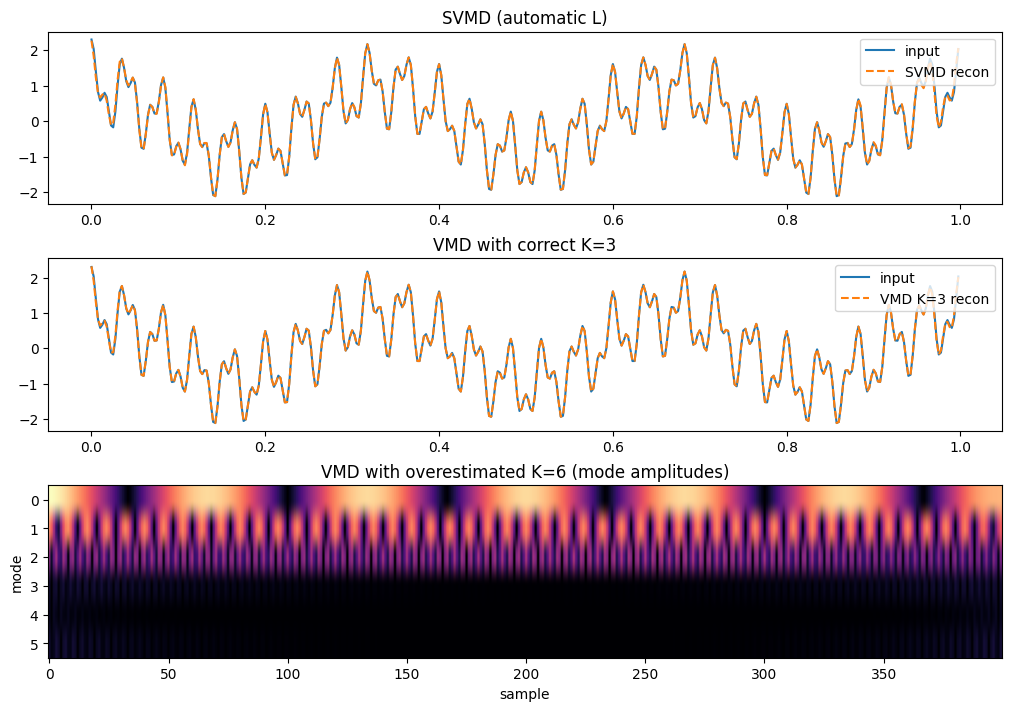

SVMD L = 3 | VMD K=3 modes = 3 | VMD K=6 modes = 6


In [6]:
# VMD with the correct K
vmd_ok = VMD(alpha=2000, K=3, tau=0.0, tol=1e-6, max_iter=300)
u_vmd = vmd_ok.fit_transform(signal)

# VMD with an overestimated K
vmd_over = VMD(alpha=2000, K=6, tau=0.0, tol=1e-6, max_iter=300)
u_over = vmd_over.fit_transform(signal)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), constrained_layout=True)
axes[0].plot(t, signal, label="input")
axes[0].plot(t, modes.sum(0), "--", label="SVMD recon")
axes[0].legend(loc="upper right")
axes[0].set_title("SVMD (automatic L)")

axes[1].plot(t, signal, label="input")
axes[1].plot(t, u_vmd.sum(0), "--", label="VMD K=3 recon")
axes[1].legend(loc="upper right")
axes[1].set_title("VMD with correct K=3")

axes[2].imshow(np.abs(u_over), aspect="auto", cmap="magma")
axes[2].set_title("VMD with overestimated K=6 (mode amplitudes)")
axes[2].set_ylabel("mode")
axes[2].set_xlabel("sample")
plt.show()

print(
    "SVMD L =",
    modes.shape[0],
    "| VMD K=3 modes =",
    u_vmd.shape[0],
    "| VMD K=6 modes =",
    u_over.shape[0],
)

## 7. Stopping criteria at a glance

`stopc=4` (power of the last mode) is the MATLAB default and is more conservative / may return extra weak modes.  `stopc=2` is better for clean synthetic data.


In [7]:
for stopc in (2, 4):
    u_s, _, om_s = SVMD(max_alpha=5000, stopc=stopc, max_iter=250).fit_transform(
        signal, return_all=True
    )
    err = np.linalg.norm(u_s.sum(0) - signal) / np.linalg.norm(signal)
    print(
        f"stopc={stopc}: L={u_s.shape[0]}, omega={np.round(om_s, 4)}, rel_err={err:.3e}"
    )

stopc=2: L=3, omega=[0.0075 0.0625 0.15  ], rel_err=3.321e-02
stopc=4: L=5, omega=[0.0075 0.0397 0.0625 0.15   0.1709], rel_err=2.175e-02


## 8. API summary

```python
from pysdkit import SVMD, svmd

svmd_c = SVMD(max_alpha=20000, tau=0.0, tol=1e-6, stopc=4)
modes = svmd_c.fit_transform(signal)                 # (L, N)
modes, u_hat, omega = svmd_c.fit_transform(signal, return_all=True)

# functional shortcut
modes = svmd(signal, max_alpha=20000, stopc=4)
```

### Practical tips

- Start with `max_alpha` around `2e3–2e4` (compactness).
- Use `tau=0` when the signal is noisy.
- Prefer `stopc=2` for clean signals, `stopc=1` for EEG-like compact spectra, `stopc=4` as a general default.
- Input length should be even; odd lengths are truncated by one sample (same as the MATLAB toolbox).


## 9. Takeaways

| | VMD | SVMD |
|--|--|--|
| Mode extraction | concurrent | successive |
| Need `K`? | yes | no (automatic stop) |
| Cost vs `K` | grows with `K` | typically lighter |
| Sensitivity to $\omega$ init | higher | more robust (paper) |

SVMD is the right tool when you want VMD-quality compact modes **without guessing the number of modes**.
